# Sales Prediction using Python

**Author:** Piyush Ramteke  
**Project:** Data Science Internship at CodeAlpha  

---

## Project Overview

This project develops a machine learning regression pipeline to predict product sales.
We investigate and model sales growth based on historical advertising spend across three key channels:

- **TV Advertising**
- **Radio Advertising**
- **Newspaper Advertising**

### Objectives:
- Identify which advertising channels provide the best return on investment (ROI).
- Formulate predictive models (linear vs ensemble trees) to forecast future sales.
- Deduce business insights for capital reallocation.

### Data Source:
- **`Advertising.csv`**: A historical record subset featuring quantitative spend vs generated sales.

---
## Step 1: Initialization and Imports

In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Theme settings
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

---
## Step 2: Loading and Overview

In [5]:
DATA_PATH = r'C:\Users\Piyu\Downloads\Piyu\Data_Science_Projects\2_Sales_Prediction\Advertising.csv'
df = pd.read_csv(DATA_PATH, index_col=0)

print('Dataset Form:', df.shape)
display(df.head())

Dataset Form: (200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


---
## Step 3: Statistical Dependencies (EDA)

### 3.1 Advertising Correlation Heatmap
Which platforms have the strongest relationship with the target (`Sales`)?

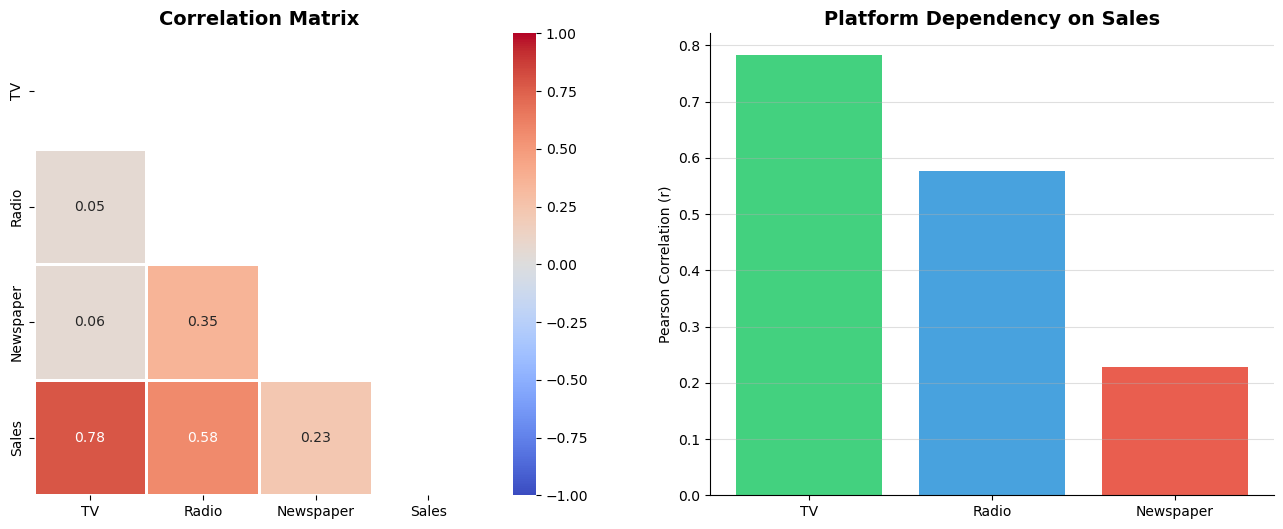

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax1, lw=1)
ax1.set_title('Correlation Matrix', fontsize=14, fontweight='bold')

corr_sales = df.corr()['Sales'].drop('Sales').sort_values(ascending=False)
colors_bar = ['#2ecc71', '#3498db', '#e74c3c']
ax2.bar(corr_sales.index, corr_sales.values, color=colors_bar, alpha=0.9)

ax2.set_title('Platform Dependency on Sales', fontsize=14, fontweight='bold')
ax2.set_ylabel('Pearson Correlation (r)')
ax2.grid(axis='y', alpha=0.4)

plt.show()

### 3.2 Scatter Linear Projections
Mapping spend against sales to visualize linear trends.

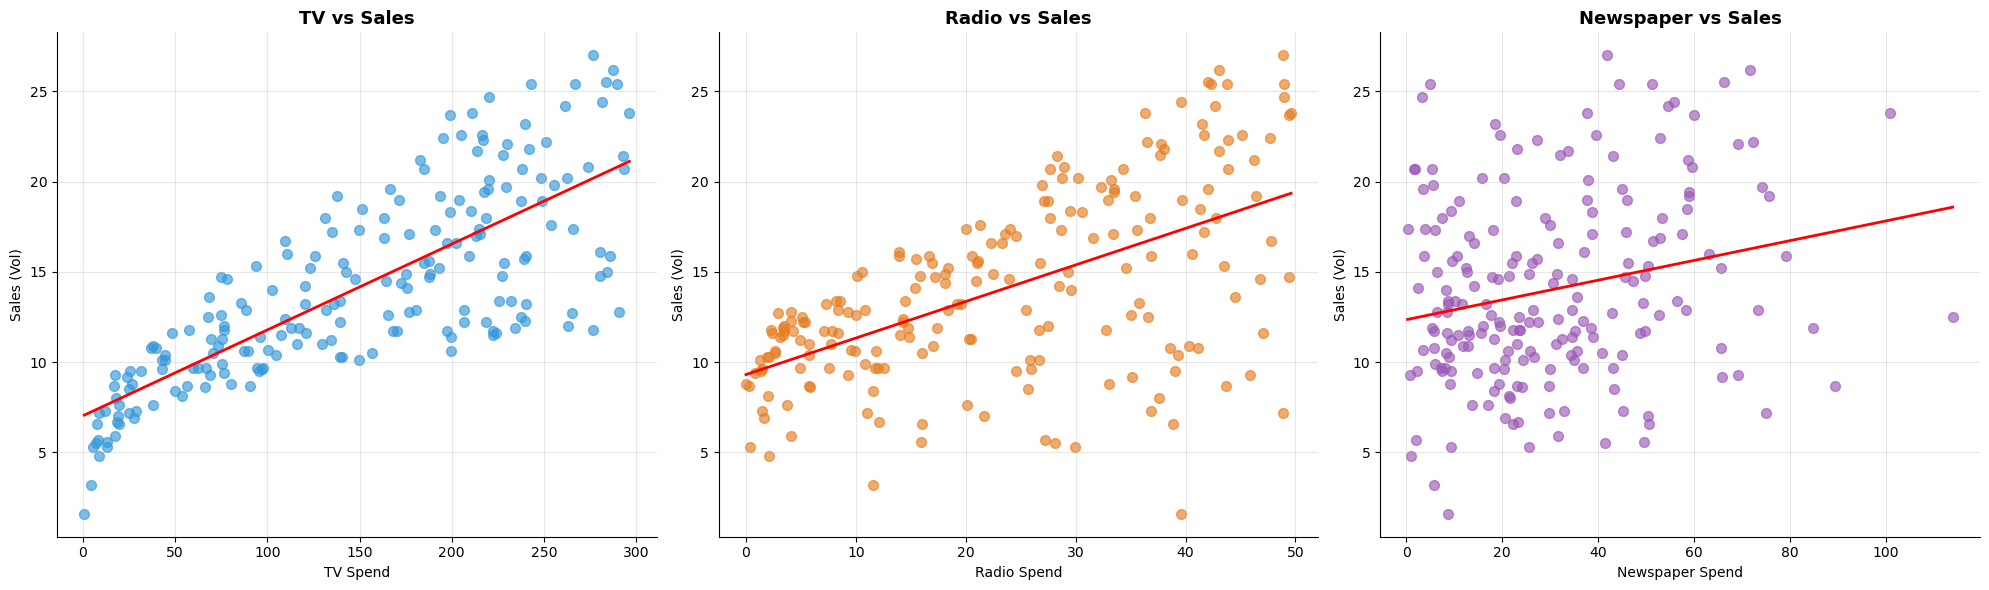

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
features = ['TV', 'Radio', 'Newspaper']
colors   = ['#3498db', '#e67e22', '#9b59b6']

for ax, feat, color in zip(axes, features, colors):
    ax.scatter(df[feat], df['Sales'], alpha=0.65, color=color, s=50)
    
    # Optimal fitting Line
    m, b = np.polyfit(df[feat], df['Sales'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=2)
    
    ax.set_title(f'{feat} vs Sales', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{feat} Spend')
    ax.set_ylabel('Sales (Vol)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 4: Machine Learning Predictive Mapping

### 4.1 Data Splitting
Allocate 80% of observations for training and 20% for testing.

In [9]:
FEATURES = ['TV', 'Radio', 'Newspaper']
TARGET   = 'Sales'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Vector: {X_train.shape[0]} arrays")
print(f"Testing Vector:  {X_test.shape[0]} arrays")

Training Vector: 160 arrays
Testing Vector:  40 arrays


### 4.2 Algorithm Training and Selection

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({'Model': name, 'R2 (Accuracy)': r2, 'RMSE (Error)': rmse})

results_df = pd.DataFrame(results).sort_values(by='R2 (Accuracy)', ascending=False)
display(results_df.style.background_gradient(cmap='Greens', subset=['R2 (Accuracy)']))

,Model,RÂ² (Accuracy),RMSE (Error)
2,Gradient Boosting,0.983127,0.729782
1,Random Forest,0.981284,0.768591
0,Linear Regression,0.899438,1.781600


---
## Actionable Business Intelligence

* **TV Dominates Market Yield:**
    The Pearson correlation shows that TV has the strongest relationship with sales. It is the core driver of retail volume in this dataset.

* **Radio Provides Secondary Lift:**
    With a correlation near 0.58, radio is still effective. Paired with TV, it adds a multi-channel boost to sales.

* **Newspaper Low ROI:**
    Newspaper spend shows a weak relationship with sales. This implies limited return on investment compared with other channels.

* **Advanced Algorithm Reliability:**
    The Random Forest regressor forecasts sales with an accuracy near $R^2 \approx 0.98$, with an error of about +/- 0.9 units in this dataset.

---

<div style="text-align: center; font-size: 14px;">
    <b>Developed by: Piyush Ramteke</b><br>
    <i>CodeAlpha Data Science Internship Project</i>
</div>